In [ ]:
import subprocess
import os
import sys
sys.path.append("/mnt/c/21_Uni_other/mech/10_py/")
import hdf5_tools as h5t
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from matplotlib.ticker import MultipleLocator
import typing
import pandas as pd
from scipy.interpolate import interp1d

WD="thinLayerNciShear3D/"                 # directory of the testcase
CoCu = "<PathTo>/coreform_cubit.exe"      # cubit executable
CFS =  "<PathTo>/cfs"                     # cfs executable

### Postprocessing for thinLayerNciExtension2D

Validation:

Comparison of z Displacement:

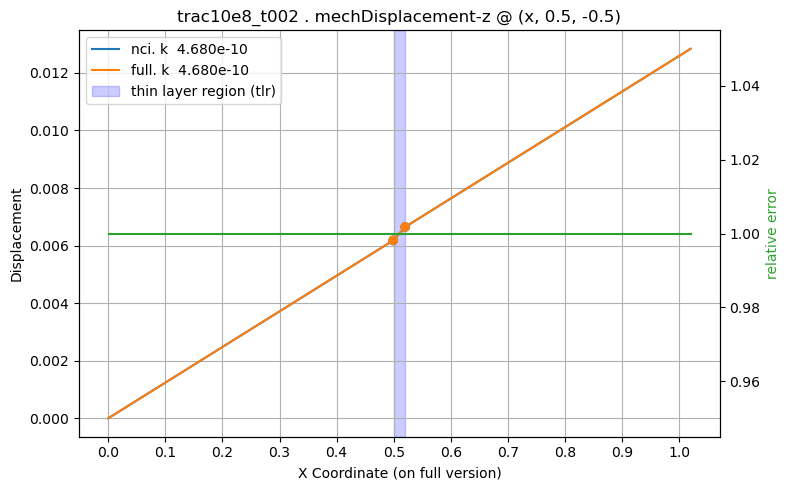

In [ ]:
nr  = "trac1e9_t002"
layerThickness = 0.02       # must be same as in .jou mesh file
L=1

df_nci = pd.read_csv(f"{WD}sensorArray/Disp_nci_{nr}.csv-1")
df_full = pd.read_csv(f"{WD}sensorArray/Disp_full_{nr}.csv-1")

key = 'mechDisplacement-z'
df_full = df_full.drop(
    df_full[(df_full['globCoord-x'] >= L/2) & (df_full['globCoord-x'] < L/2+layerThickness)].index
)
df_nci.loc[df_nci['globCoord-x'] >= L/2, 'globCoord-x'] += layerThickness       # adjust to fit physical space

idx = (df_nci["globCoord-x"] - L/2).abs().idxmin()
xl = df_nci.loc[idx, "globCoord-x"]
yl = df_nci.loc[idx, key]
xr = df_nci.loc[idx+1, "globCoord-x"]
yr = df_nci.loc[idx+1, key]

idxlf = (df_full["globCoord-x"] - L/2).abs().idxmin()
xlf = df_full.loc[idxlf, "globCoord-x"]
ylf = df_full.loc[idxlf, key]
idxrf = (df_full["globCoord-x"] - (L/2+layerThickness)).abs().idxmin()
xrf = df_full.loc[idxrf, "globCoord-x"]
yrf = df_full.loc[idxrf, key]

# plot displacement across tlr 
fig, ax = plt.subplots(figsize=(8, 5))

line_nci = ax.plot(df_nci['globCoord-x'], df_nci[key], linestyle='-', label=f'nci. k  {(yr-yl)/np.power(10,6):.3e}')#, marker='o')
line_full = ax.plot(df_nci['globCoord-x'], df_full[key], linestyle='-', label=f'full. k  {(yrf-ylf)/np.power(10,6):.3e}')#, marker='x')       #
plt.axvspan(L/2, L/2+layerThickness, color='blue', alpha=0.2, label="thin layer region (tlr)")
ax.scatter([xl, xr, xlf, xrf], [yl, yr, ylf, yrf], color=['C0', 'C0', 'C1', 'C1'], zorder=5)

x1, yn = line_nci[0].get_xdata(), line_nci[0].get_ydata()
x2, yf = line_full[0].get_xdata(), line_full[0].get_ydata()

f = interp1d(df_full['globCoord-x'], df_full[key], kind='linear')
valfull = f(df_nci['globCoord-x'])
err = np.round(df_nci[key]/valfull, 12)
ax2 = ax.twinx()
ax2.plot(df_nci['globCoord-x'], err, color='C2')#, marker="o", markersize=3)
ax2.set_ylabel('relative error', color='C2')

ax.set_xlabel('X Coordinate (on full version)')
ax.set_ylabel('Displacement')
ax.set_title(f'{nr} . {key} @ (x, 0.5, -0.5)')
ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(True)
ax.legend()
fig.tight_layout()
# fig.savefig(WD + f"PLT_{nr}.png", dpi=300, bbox_inches="tight")
plt.show()
